## Project Two

Rainfall in Adelaide Pooraka Australia
source: https://reg.bom.gov.au/jsp/ncc/cdio/weatherData/avp_nccObsCode=136&p_display_type=dailyDataFile&p_startYear=2004&p_c=-106196544&p_stn_num=023026 

about the data: https://reg.bom.gov.au/climate/cdo/about/about-rain-data.shtml

note: make a cell a text cell by having it selected and using "Esc" "M"
      
      make text bold **bold**

In [1]:
#setting up environment
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

In [2]:
os.listdir()

['.ipynb_checkpoints', 'aus_weather_023026.csv', 'Project2.ipynb']

In [3]:
#importing data
ad = pd.read_csv("aus_weather_023026.csv")
ad.head()

,Product code,Bureau of Meteorology station number,Year,Month,Day,Rainfall amount (millimetres),Period over which rainfall was measured (days),Quality
0,IDCJAC0009,23026,1878,1,1,0.0,NaN,Y
1,IDCJAC0009,23026,1878,1,2,0.0,NaN,Y
2,IDCJAC0009,23026,1878,1,3,0.0,NaN,Y
3,IDCJAC0009,23026,1878,1,4,0.0,NaN,Y
4,IDCJAC0009,23026,1878,1,5,0.0,NaN,Y


##  Data exploration (EDA)
1. Evaluate your variables
2. Clean the data
3. Evaluate associations and structure in the data
4. Explain initial impressions

In [4]:
#Exploring some of the values in the columns
display(ad['Product code'].unique(),
        ad['Bureau of Meteorology station number'].unique(),
        ad['Period over which rainfall was measured (days)'].unique(),
        ad['Quality'].unique(),
        ad['Year'].unique(),
        len(ad['Year'].unique()),
        len(ad)
       )

array(['IDCJAC0009'], dtype=object)

array([23026], dtype=int64)

array([nan,  1.,  2.,  3.,  5.,  4.,  8.,  7.,  6.])

array(['Y', nan, 'N'], dtype=object)

array([1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888,
       1889, 1890, 1891, 1892, 1893, 1894, 1895, 1896, 1897, 1898, 1899,
       1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908, 1909, 1910,
       1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921,
       1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932,
       1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941, 1942, 1943,
       1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954,
       1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965,
       1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976,
       1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987,
       1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998,
       1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009,
       2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
       2021, 2022, 2023], dtype=int64)

146

53111

## Cleaning the data

In [5]:
ad.columns

Index(['Product code', 'Bureau of Meteorology station number', 'Year', 'Month',
       'Day', 'Rainfall amount (millimetres)',
       'Period over which rainfall was measured (days)', 'Quality'],
      dtype='object')

The columns 'Product code' and 'Bureau of Meteorology station number' only contain one value because they're just informational as to where the data was recorded. Meaning they are not helpful to our analysis and we can drop them.

In [6]:
ad_clean = ad.copy()
ad_clean = ad_clean.drop(columns=['Product code', 'Bureau of Meteorology station number'])
ad_clean.head(5)

,Year,Month,Day,Rainfall amount (millimetres),Period over which rainfall was measured (days),Quality
0,1878,1,1,0.0,NaN,Y
1,1878,1,2,0.0,NaN,Y
2,1878,1,3,0.0,NaN,Y
3,1878,1,4,0.0,NaN,Y
4,1878,1,5,0.0,NaN,Y


The 'Quality' column contain values ['Y', nan, 'N'] and represents if the data was quality controlled, we want only the data that was recorded with 'Y' or NaN.

In [7]:
#which rows have 'N' values
ad_clean[ad_clean['Quality'] == 'N']['Year'].value_counts()

Year
2021    292
2022    223
2020    221
2023     60
2000      2
Name: count, dtype: int64

In [8]:
count_q = (ad_clean['Quality'].value_counts()).reset_index()
count_q

,Quality,count
0,Y,48379
1,N,798


In [9]:
#how many rows have 'nan' values?
print('number of NaN values in Quality:', len(ad_clean) - (count_q['count'][0] + count_q['count'][1]))

#where are the NaN values?
ad_clean[ad_clean['Quality'].isna()]['Year'].value_counts()

number of NaN values in Quality: 3934


Year
1880    366
1881    365
1883    365
1879    365
1882    337
       ... 
1906      1
1894      1
1895      1
1896      1
1913      1
Name: count, Length: 138, dtype: int64

In [10]:
#from filtering the data this way we lost 4,732 rows of data or 9% of the data which may not be a lot but could effect our annalysis later. 
ad_clean = ad_clean[(ad_clean['Quality'] == 'Y') | (ad_clean['Quality'].isna())]

#now that 'Quality' is filtered we can drop the column
ad_clean = ad_clean.drop(columns=['Quality'])
print(len(ad_clean))
ad_clean.head(3)

52313


,Year,Month,Day,Rainfall amount (millimetres),Period over which rainfall was measured (days)
0,1878,1,1,0.0,NaN
1,1878,1,2,0.0,NaN
2,1878,1,3,0.0,NaN


Now lets look at the "Period over which rainfall was measured (days)" column. First lets re name two of the columns for ease of use then look at the rows with values that are NOT 'nan'. 

In [11]:
#rename columns
ad_clean = ad_clean.rename(columns={'Rainfall amount (millimetres)':'Rainfall (MM)', 'Period over which rainfall was measured (days)':'Period Measured (days)'})

#filter out NaN values
period = ad_clean.dropna()

#lets see if the higher days disproportionatly influance the rainfall amount
period_rf_days = period[['Rainfall (MM)','Period Measured (days)']]
display(period_rf_days['Period Measured (days)'].value_counts(),
        period_rf_days.groupby('Period Measured (days)').mean()
       )

#lets compare the means grouped by period measured to the total mean
print('Rainfall mean for whole data set = ', ad_clean['Rainfall (MM)'].mean())

Period Measured (days)
1.0    13361
2.0      661
3.0      323
4.0       24
5.0        3
6.0        2
8.0        1
7.0        1
Name: count, dtype: int64

,Rainfall (MM)
Period Measured (days),
1.0,4.295008
2.0,7.577307
3.0,8.229102
4.0,15.150000
5.0,14.066667
6.0,8.100000
7.0,10.800000
8.0,15.400000


Rainfall mean for whole data set =  1.353901486182021


**Testing effect of greater than one values in Period Measured (days).**

In [12]:
#group 1 is the data where Period measured (days) = 1 or nan
one = [1]
group_1 = ad_clean[ad_clean['Period Measured (days)'].isin(one) | ad_clean['Period Measured (days)'].isna()]
group_1 = group_1[['Rainfall (MM)', 'Period Measured (days)']]

#group 2 is the data where period measured (days) is greater than 1
two = [2, 3, 4, 5, 6, 7,8]
group_2 = ad_clean[ad_clean['Period Measured (days)'].isin(two)]
group_2 = group_2[['Rainfall (MM)', 'Period Measured (days)']]

display(group_1, group_2)

,Rainfall (MM),Period Measured (days)
0,0.0,NaN
1,0.0,NaN
2,0.0,NaN
3,0.0,NaN
4,0.0,NaN
...,...,...
53075,0.0,NaN
53076,4.4,1.0
53077,1.8,1.0
53078,0.0,NaN


,Rainfall (MM),Period Measured (days)
2211,16.0,2.0
2295,4.3,2.0
2540,8.9,2.0
2820,8.9,2.0
2939,2.8,2.0
...,...,...
52436,14.2,3.0
52786,1.2,3.0
52793,10.2,3.0
52989,12.8,3.0


In [13]:
(group_1['Rainfall (MM)'].value_counts())
#max(group_1['Rainfall (MM)'])

Rainfall (MM)
0.0     34451
0.3      1128
0.8       862
0.5       791
1.0       622
        ...  
39.6        1
33.2        1
63.8        1
55.4        1
65.4        1
Name: count, Length: 286, dtype: int64

In [14]:
(group_2.sort_values('Rainfall (MM)')['Rainfall (MM)'].value_counts())

Rainfall (MM)
2.8     38
3.0     32
3.8     32
0.4     23
2.5     23
        ..
21.4     1
21.3     1
21.0     1
20.2     1
65.0     1
Name: count, Length: 196, dtype: int64

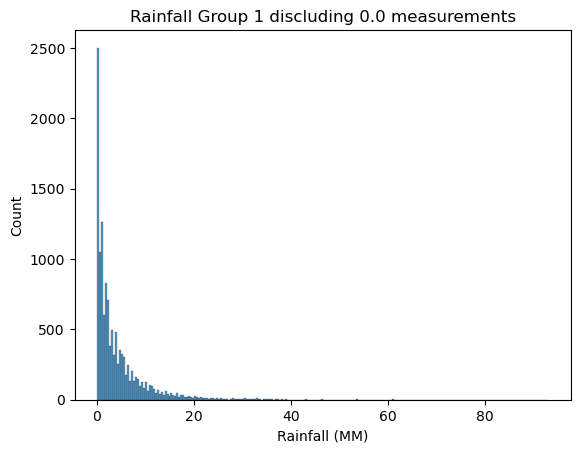

In [15]:
sns.histplot(group_1[group_1['Rainfall (MM)'] > 0.0]['Rainfall (MM)'])
#I had to cut out vales at 0.0 MM of rainfall because it had a count of 34k and next lowest was 1k
plt.title('Rainfall Group 1 discluding 0.0 measurements');

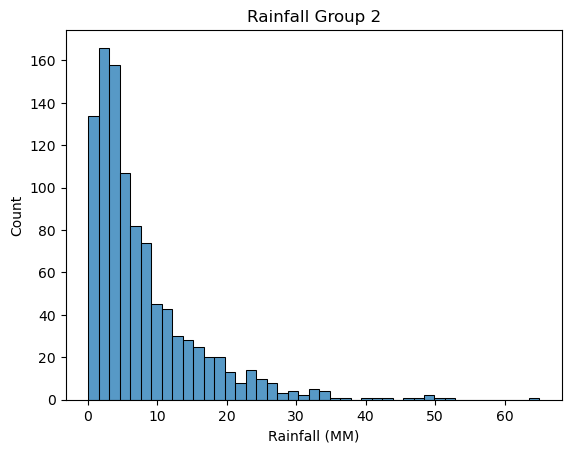

In [16]:
#plt.figure(figsize=(20, 100))
sns.histplot(group_2['Rainfall (MM)'])
plt.title('Rainfall Group 2');

Because the data is not normally distributed it's best to find the difference in means between group 1 and 2 and then re test it many times with random groups and test the difference in means again.

In [17]:
orig_dif_mean = np.mean(group_1['Rainfall (MM)']) - np.mean(group_2['Rainfall (MM)'])
print('Difference in mean between group 1 and 2', orig_dif_mean)

n_1 = len(group_1)
n_2 = len(group_2)
means = []

#train test split
for n in range(1000):
    g1, g2 = train_test_split(ad_clean, test_size=n_1, train_size=n_2)
    means.append(np.mean(g1['Rainfall (MM)']) - np.mean(g2['Rainfall (MM)']))

p_value = np.mean([abs(m) >= abs(orig_dif_mean) for m in means])
print('P-value = ', p_value)

Difference in mean between group 1 and 2 -6.783289988072669
P-value =  0.0


Because the p_value for 1,000 tests is close to 0.0 (a very low p-value) we can say that it's likely that a larger day amount does have an effect on the data. So we should filter our data more to take out these values if we're looking at the data split by day, by month or year it doesn't make much of a difference because the values are accumulated rainfall. 

In [18]:
ad.iloc[2207:2213]

,Product code,Bureau of Meteorology station number,Year,Month,Day,Rainfall amount (millimetres),Period over which rainfall was measured (days),Quality
2207,IDCJAC0009,23026,1884,1,17,3.3,1.0,Y
2208,IDCJAC0009,23026,1884,1,18,0.0,NaN,Y
2209,IDCJAC0009,23026,1884,1,19,0.0,NaN,Y
2210,IDCJAC0009,23026,1884,1,20,NaN,NaN,NaN
2211,IDCJAC0009,23026,1884,1,21,16.0,2.0,Y
2212,IDCJAC0009,23026,1884,1,22,0.8,1.0,Y


In [19]:
#ad_clean = ad_clean[ad_clean['Period Measured (days)'].isin(one) | ad_clean['Period Measured (days)'].isna()]

#now that we've cleaned our "Period Measured (days)" column we no longer need it
ad_clean = ad_clean.drop(columns=['Period Measured (days)'])
ad_clean.head(5)

,Year,Month,Day,Rainfall (MM)
0,1878,1,1,0.0
1,1878,1,2,0.0
2,1878,1,3,0.0
3,1878,1,4,0.0
4,1878,1,5,0.0


Let's try grouping by month and year now. We'll go back to the non clean data for this. 

In [20]:
ad_imp = ad.copy()
ad_imp = ad_imp[['Year', 'Month', 'Day', 'Rainfall amount (millimetres)']]

ad_month_yr = ad_imp.groupby(['Year', 'Month']).sum()
ad_month_yr

Day  Rainfall amount (millimetres)
Year Month                                    
1878 1      496                            0.0
     2      406                            0.0
     3      496                            0.0
     4      465                            0.0
     5      496                            0.0
...         ...                            ...
2023 1      496                           12.8
     2      406                            7.4
     3      496                           31.4
     4      465                           20.2
     5      496                           75.1

[1745 rows x 2 columns]

We would expect there to be about 4,380 days for each value count of month because there's 146 unique years and 28-31 days in a month. Remember that we have an observation of data (row) for each day.  

[1, 3, 5, 7, 8, 10, 12] = 4526 days

[4, 6, 9, 11] = 4350 days

[2] = Febuary is weird because it normally has 28 days or 29 on a leap year

In [21]:
ad['Month'].value_counts()

Month
1     4526
3     4526
5     4526
7     4495
8     4495
10    4495
12    4495
4     4380
6     4350
9     4350
11    4350
2     4123
Name: count, dtype: int64

Great! it looks like our value counts are what we would expect.

In [22]:
#lets compair January rain to August rain
jan_aug = ad_imp[(ad_imp['Month'] == 1) | (ad_imp['Month'] == 8)]
jan_aug = jan_aug.groupby('Month').sum()
jan_aug

,Year,Day,Rainfall amount (millimetres)
Month,,,
1,8827963,72416,2788.9
8,8765250,71920,7838.3


Rainfall in August is higher than rainfall in January

## Exploring Year
Because Year will be one of the main variables in our data let's explore it first. 

In [23]:
early = min(ad_clean['Year'])
late = max(ad_clean['Year'])
print('The first year recorded is:', early, 'most recent year is:', late)

The first year recorded is: 1878 most recent year is: 2023


In [24]:
len(ad_clean['Year'].unique())

146

In [25]:
ad['Year'].value_counts().value_counts()

count
365    110
366     35
151      1
Name: count, dtype: int64

Most of the 146 years have 366 or 365 counts with the exception of 2023. This makes sense because a year has 365 days and leap years have 366.
lets look at the years with 366 values and make sure they are leap years. Because 2023 is not complete we are going to drop it. 

Note: This analysis was done on the original 'ad' dataframe not on 'ad_clean' because ad_clean already has values taken out and would not properly represet the number of days in that year. 

In [26]:
years = (ad_clean['Year'].value_counts() == 366).reset_index()
leap_year_ad = years[years['count'] == True]['Year']
leap_year_ad

#Because leap years are divisible by 4 except for years divisible by 100 but not 400 we can write an equation
def is_leap_yr(year):
    #returns a boolian value if the year is a leap year or not
    return (year % 4 == 0) and (year % 100 != 0 or year % 400 == 0)

np.sum(leap_year_ad.apply(is_leap_yr)) / len(leap_year_ad)
#yay all the years with 366 values are leap years meaning there is not any abnormal data enteries

1.0

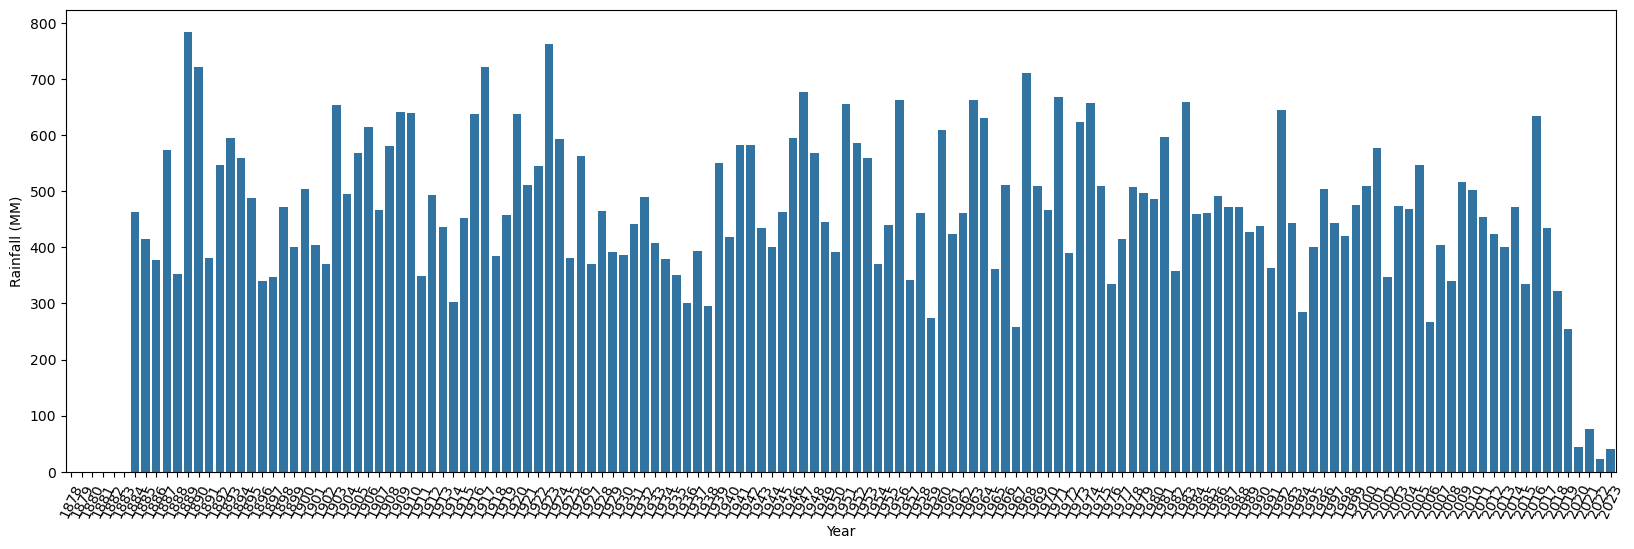

In [27]:
#in this plot each bar is a year
plt.figure(figsize=(20, 6))
ad_year = ad_clean.groupby('Year')['Rainfall (MM)'].sum().reset_index()
sns.barplot(data=ad_year, x='Year', y='Rainfall (MM)')
plt.xticks(rotation=65);

**Distribution split by years**

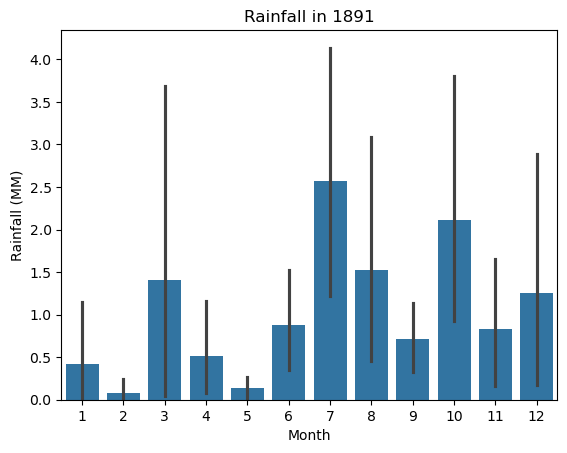

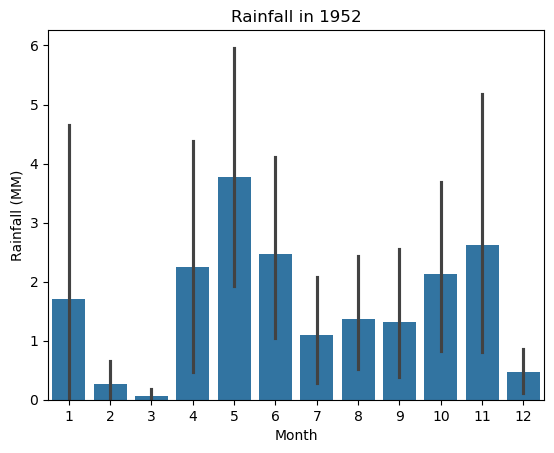

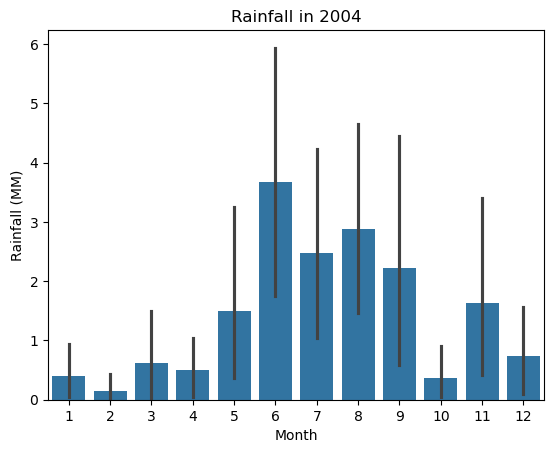

In [28]:
plt.figure()
yr_18 = ad_clean[ad_clean['Year'] == 1891]
sns.barplot(data=yr_18, x='Month', y='Rainfall (MM)')
plt.title('Rainfall in 1891')

plt.figure()
yr_19 = ad_clean[ad_clean['Year'] == 1952]
sns.barplot(data=yr_19, x='Month', y='Rainfall (MM)')
plt.title('Rainfall in 1952')

plt.figure()
yr_20 = ad_clean[ad_clean['Year'] == 2004]
sns.barplot(data=yr_20, x='Month', y='Rainfall (MM)')
plt.title('Rainfall in 2004');

**plots**

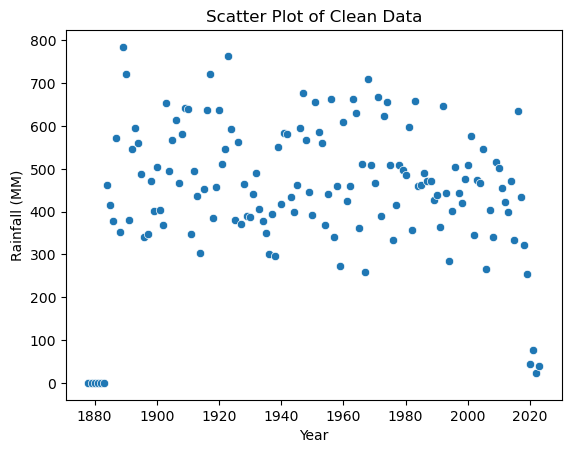

In [29]:
sns.scatterplot(data=ad_year, x='Year', y='Rainfall (MM)')
plt.title('Scatter Plot of Clean Data');

Most noticably there are outliers near 1880 and 2020 where the tottal rainfall for that year was 0 or less than 100. These years we probably want to drop because they seem most effected by how we've filtered the data so far. Specifically the most recent years would be affected because the quality of them hasn't been checked yet and could have 'N' values which we dropped. 

In [30]:
low_yr = ad_year[ad_year['Rainfall (MM)'] < 150]

data_low = ad[ad['Year'].isin(low_yr['Year'])]
data_low = data_low[['Year', 'Rainfall amount (millimetres)']]

display(
    low_yr,
data_low.groupby('Year').sum()
)

ad_clean = ad_clean[~ad_clean['Year'].isin(low_yr['Year'])]
ad_clean['Year'].unique()

,Year,Rainfall (MM)
0,1878,0.0
1,1879,0.0
2,1880,0.0
3,1881,0.0
4,1882,0.0
5,1883,0.0
142,2020,43.7
143,2021,76.2
144,2022,23.2
145,2023,40.4


,Rainfall amount (millimetres)
Year,
1878,0.0
1879,0.0
1880,0.0
1881,0.0
1882,0.0
1883,0.0
2020,362.1
2021,323.1
2022,390.9


array([1884, 1885, 1886, 1887, 1888, 1889, 1890, 1891, 1892, 1893, 1894,
       1895, 1896, 1897, 1898, 1899, 1900, 1901, 1902, 1903, 1904, 1905,
       1906, 1907, 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915, 1916,
       1917, 1918, 1919, 1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927,
       1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938,
       1939, 1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949,
       1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960,
       1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019], dtype=int64)

**Heatmap**

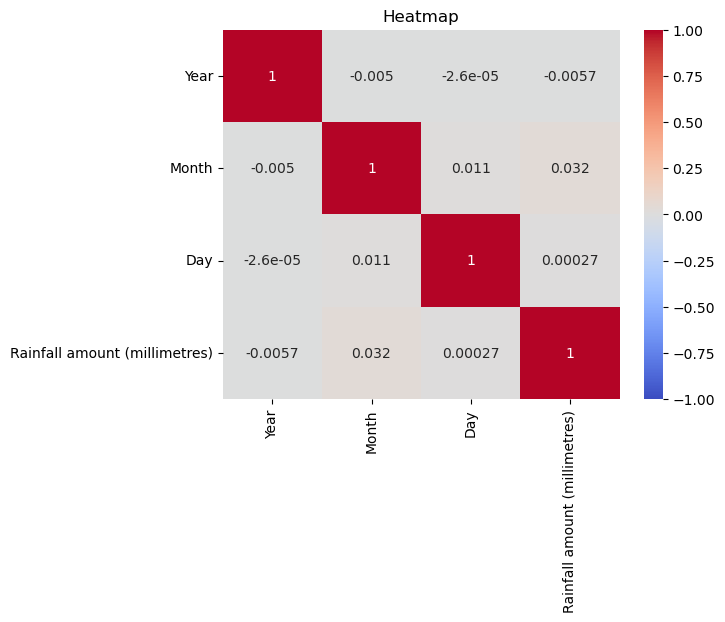

In [31]:
#creating a heatmap

ad_corr = ad_imp.corr()
sns.heatmap(ad_corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title('Heatmap');

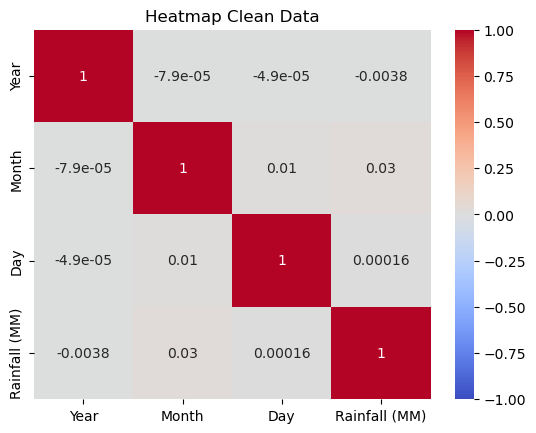

In [32]:
ad_clean_corr = ad_clean.corr()
sns.heatmap(ad_clean_corr, annot=True, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title('Heatmap Clean Data');

From the heatmap we can notice two things, first Month and Rainfall have the highest positive corrilation. Second, Rainfall and Year has a negative corrilation which might point to global warming effecting rainfall.

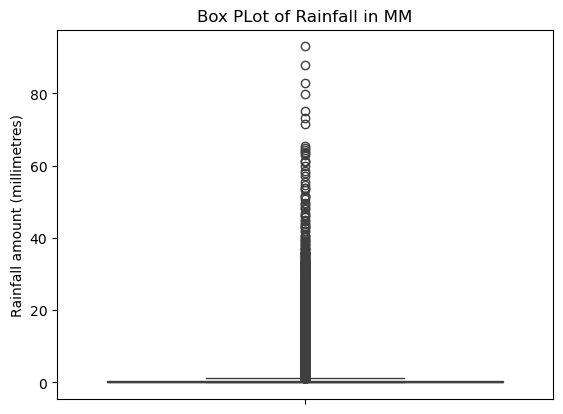

In [33]:
#lets explore outliers using a boxplot

sns.boxplot(data=ad_imp, y='Rainfall amount (millimetres)')
plt.title('Box PLot of Rainfall in MM');

Wow! There are a lot of outliers. This is somewhat expected though because the distribution is not normal but there is a slight coorilation between some of the variables. 

In [34]:
#Interquartile Range to find outliers
Q1 = ad_imp['Rainfall amount (millimetres)'].quantile(0.25)
Q3 = ad_imp['Rainfall amount (millimetres)'].quantile(0.75)
IQR = Q3 - Q1

# Define outliers
outliers = ad_imp[(ad_imp['Rainfall amount (millimetres)'] < (Q1 - 1.5 * IQR)) | (ad_imp['Rainfall amount (millimetres)'] > (Q3 + 1.5 * IQR))]
outliers

,Year,Month,Day,Rainfall amount (millimetres)
2207,1884,1,17,3.3
2211,1884,1,21,16.0
2214,1884,1,24,4.1
2215,1884,1,25,11.9
2216,1884,1,26,9.1
...,...,...,...,...
53099,2023,5,20,4.6
53100,2023,5,21,5.3
53108,2023,5,29,18.2
53109,2023,5,30,2.2


## Initial impressions

So far it seems there might be a slight chance that rainfall amounts are decreasing due to global warming. To determine this for sure the data needs to be explored further. Looking at the average rainfall per month or year would be interesting but because of the cleaning we had to do grouping by days would no longer be valuable. If we did want to look at the rainfall more closely per day the data would have to be formatted differently to account for the recordings that had multiple days between which would be a lot more extra work for the little benifit. 

## Inference

Null Hypothosis: There has been no change in amount of rainfall.

Alternative Hypothosis: Average rainfall has gone down due to global warming. 

**Regression Plot**

The slope of the regression plot represents the change over time of rainfall amounts for the whole data set. Is the change more apparent if we split the data differently?

Lets try splitting the data in different ways... 
1. 4 even groups
2. by season

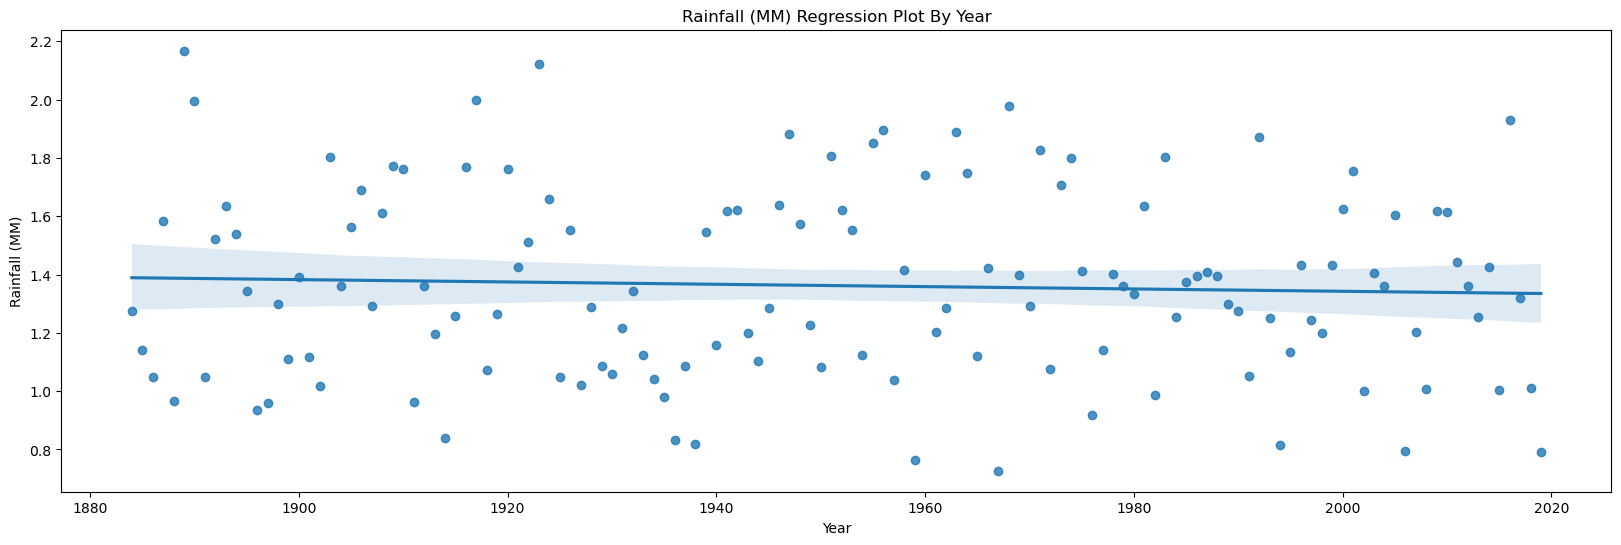

In [35]:
ad_clean_year = ad_clean.groupby('Year').mean().reset_index()

plt.figure(figsize=(20, 6))
sns.regplot(data=ad_clean_year, x='Year', y='Rainfall (MM)')
plt.title('Rainfall (MM) Regression Plot By Year');

Looking at the data as a whole let's quantify confidence by bootstraping. First lets fit the data to find the slope of the regression line then bootstrap and compair the values. 

In [36]:
x = ad_clean_year['Year'].values.reshape(-1, 1)
y = ad_clean_year['Rainfall (MM)']

model = LinearRegression()
model.fit(x, y)
slope = model.coef_[0]
slope

-0.00040073128255652834

The slope is negative which fits our alternate hypothosis so lets keep exploring.... note that it is a very low slope so if there is change its very little. 

In [37]:
#bootstrap
boot = []
for n in range(1000):
    sample_df = ad_clean_year.loc[np.random.choice(136, size=68, replace=True)]

    x = sample_df['Year'].values.reshape(-1, 1)
    y = sample_df['Rainfall (MM)']

    model = LinearRegression()
    model.fit(x, y)
    slope = model.coef_[0]
    boot.append(slope)

np.mean(boot)

-0.0003791452270415707

Our bootstrapped value of the regression line is very very close to our actual value of the regression line

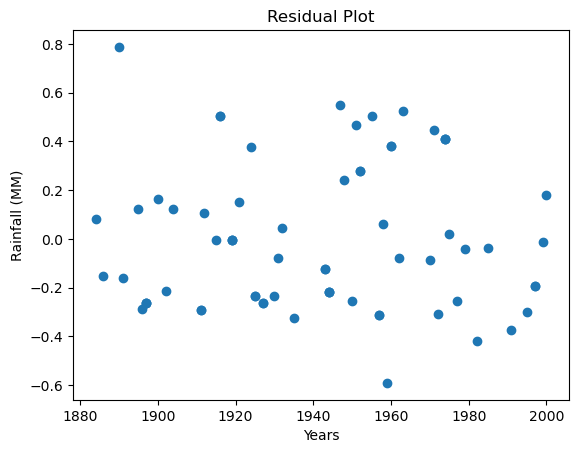

In [38]:
residuals = y - model.predict(x)
plt.scatter(x, residuals)
plt.title('Residual Plot')
plt.xlabel('Years')
plt.ylabel('Rainfall (MM)');

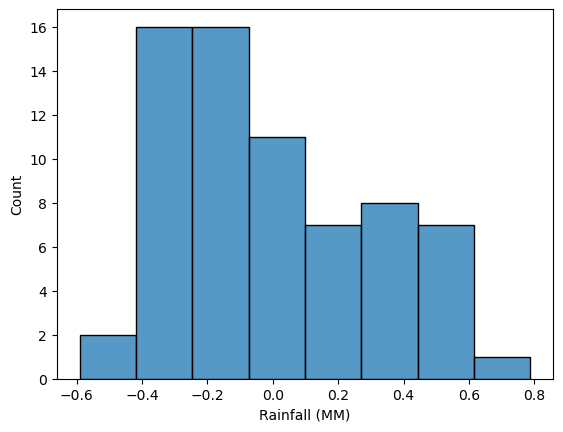

In [39]:
sns.histplot(residuals);

**1**

The regression plot above with all the data doesn't seem to have a very drastic change. To compare the change better let's split the data into four groups by year and look at each of those regression plots. 

<Axes: xlabel='Year', ylabel='Rainfall (MM)'>

<Axes: xlabel='Year', ylabel='Rainfall (MM)'>

<Axes: xlabel='Year', ylabel='Rainfall (MM)'>

<Axes: xlabel='Year', ylabel='Rainfall (MM)'>

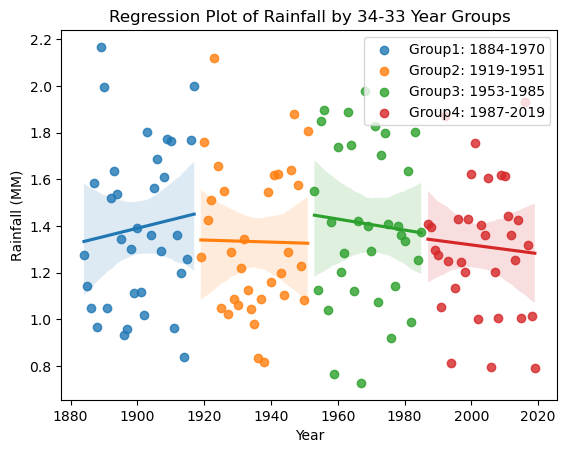

In [40]:
g1 = ad_clean_year.iloc[:34]
g2 = ad_clean_year.iloc[35:68]
g3 = ad_clean_year.iloc[69:102]
g4 = ad_clean_year.iloc[103:136]
#note: g1 has one more year because 136 can't be split completely evenly by 4.

display(
    sns.regplot(data=g1, x='Year', y='Rainfall (MM)', label='Group1: 1884-1970'),
    sns.regplot(data=g2, x='Year', y='Rainfall (MM)', label='Group2: 1919-1951'),
    sns.regplot(data=g3, x='Year', y='Rainfall (MM)', label='Group3: 1953-1985'),
    sns.regplot(data=g4, x='Year', y='Rainfall (MM)', label='Group4: 1987-2019')
)
plt.title('Regression Plot of Rainfall by 34-33 Year Groups')
plt.legend();

In [41]:
yrs = {'g1':g1, 'g2':g2, 'g3':g3, 'g4':g4}

for group, group_df in yrs.items():
    x = group_df['Year'].values.reshape(-1, 1)
    y = group_df['Rainfall (MM)']

    #Regression Line Slope
    model = LinearRegression()
    model.fit(x, y)
    slope = model.coef_[0]

    #Standard Error
    y_pred = model.predict(x)
    res = y - y_pred
    std_err = np.sqrt(np.sum(res**2) / (len(y) - 2))
    
    print('Regression Line Slope for',group, 'is', slope, 'Standard Error =', std_err)

Regression Line Slope for g1 is 0.0035565925215798647 Standard Error = 0.35075603365892183
Regression Line Slope for g2 is -0.0004381859611685497 Standard Error = 0.32234216968381113
Regression Line Slope for g3 is -0.002356911488532121 Standard Error = 0.3468563599872
Regression Line Slope for g4 is -0.001879610557465189 Standard Error = 0.2916580519007273


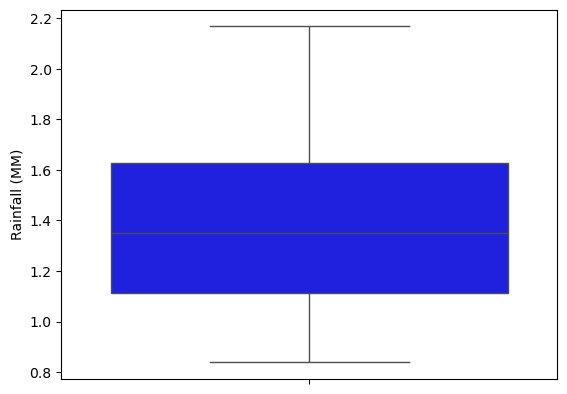

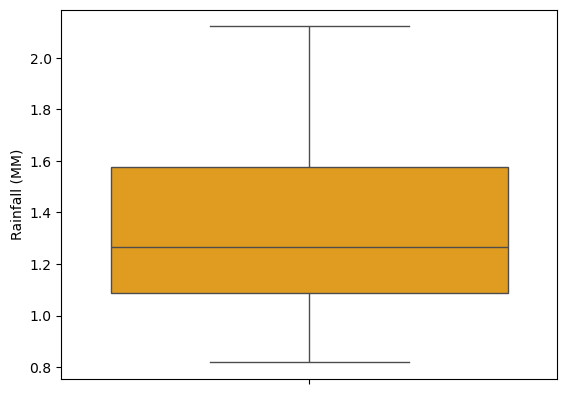

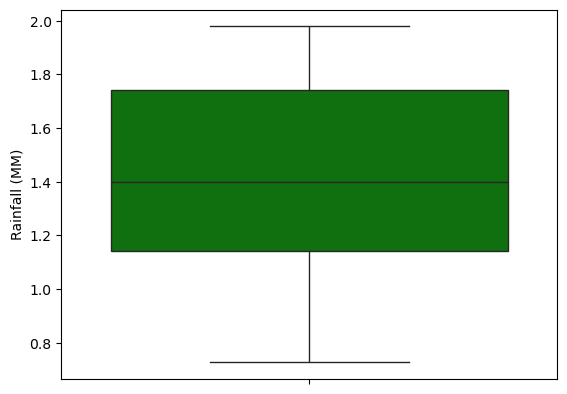

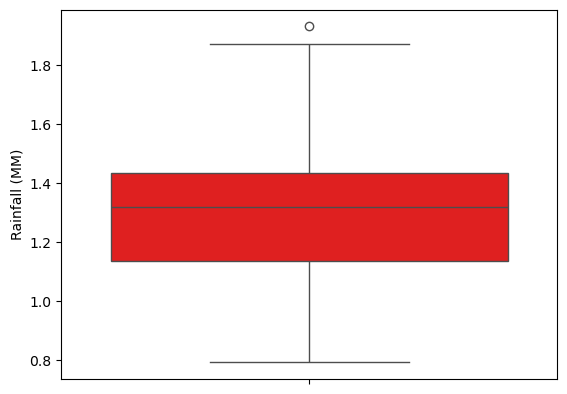

In [42]:
#Boxplots to compair distributions of data
sns.boxplot(data=g1, y='Rainfall (MM)', color='blue')
plt.show()

sns.boxplot(data=g2, y='Rainfall (MM)', color='orange')
plt.show()

sns.boxplot(data=g3, y='Rainfall (MM)', color='green')
plt.show()

sns.boxplot(data=g4, y='Rainfall (MM)', color='red')
plt.show()

Observations:

From the plot above we can more easily see how in group two the average rainfall was lower than in group one and continued to decrease. Then rainfall increased again and shows a more gradual downward trend in groups three and four. All the gorups except one have a negative slope to the regression line meaning mean rainfall is decreasing during those times. 

**2**

One of the main arguments of global warming is that summers are getting dryer and weather patterns are more drastic, lets split the data by season now and look at the change in rainfall. 

0 = Winter

1 = Spring

2 = Summer

3 = Fall

In [43]:
ad_clean_ses = ad_clean.copy()
ad_clean_ses = ad_clean_ses.dropna()
ad_clean_ses['Month'] = ad_clean_ses['Month'].replace({12:0})    #change december from 12 to 0 for easier bin assignment

bins= [0, 2, 5, 8, 11]
labels = [0, 1, 2, 3]
ad_clean_ses['Season'] = pd.cut(ad_clean_ses['Month'], bins=bins, labels=labels, right=True, include_lowest=True)
ad_clean_ses

,Year,Month,Day,Rainfall (MM),Season
2191,1884,1,1,0.0,0
2192,1884,1,2,0.0,0
2193,1884,1,3,0.0,0
2194,1884,1,4,0.0,0
2195,1884,1,5,0.3,0
...,...,...,...,...,...
51859,2019,0,27,0.0,0
51860,2019,0,28,0.0,0
51861,2019,0,29,0.0,0
51862,2019,0,30,0.0,0


<Axes: xlabel='Year', ylabel='Rainfall (MM)'>

<Axes: xlabel='Year', ylabel='Rainfall (MM)'>

<Axes: xlabel='Year', ylabel='Rainfall (MM)'>

<Axes: xlabel='Year', ylabel='Rainfall (MM)'>

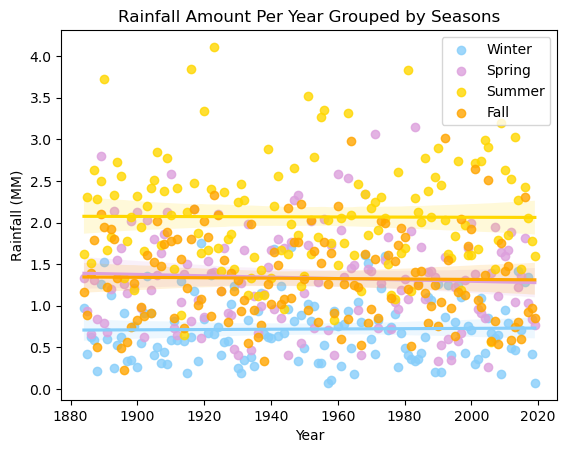

In [44]:
winter = (ad_clean_ses[ad_clean_ses['Season'] == 0]).groupby('Year')['Rainfall (MM)'].mean().reset_index()
spring = (ad_clean_ses[ad_clean_ses['Season'] == 1]).groupby('Year')['Rainfall (MM)'].mean().reset_index()
summer = (ad_clean_ses[ad_clean_ses['Season'] == 2]).groupby('Year')['Rainfall (MM)'].mean().reset_index()
fall = (ad_clean_ses[ad_clean_ses['Season'] == 3]).groupby('Year')['Rainfall (MM)'].mean().reset_index()

display(
    sns.regplot(data=winter, x='Year', y='Rainfall (MM)', label='Winter', color='lightskyblue'),
    sns.regplot(data=spring, x='Year', y='Rainfall (MM)', label='Spring', color='plum'),
    sns.regplot(data=summer, x='Year', y='Rainfall (MM)', label='Summer', color='gold'),
    sns.regplot(data=fall, x='Year', y='Rainfall (MM)', label='Fall', color='orange')
)
plt.legend()
plt.title('Rainfall Amount Per Year Grouped by Seasons');

In [45]:
seasons = {
    "Winter": winter,
    "Spring": spring,
    "Summer": summer,
    "Fall": fall
}
for season_name, season_df in seasons.items():
    x = season_df['Year'].values.reshape(-1, 1)
    y = season_df['Rainfall (MM)']

    #Regression Line Slope
    model = LinearRegression()
    model.fit(x, y)
    slope = model.coef_[0]

    #Standard Error
    y_pred = model.predict(x)
    res = y - y_pred
    std_err = np.sqrt(np.sum(res**2) / (len(y) - 2))
    
    print('Regression Line Slope for',season_name, 'is', slope, 'Standard Error =', std_err)

Regression Line Slope for Winter is 0.0001731340951167483 Standard Error = 0.39052373538098595
Regression Line Slope for Spring is -0.000829882867120657 Standard Error = 0.5897624159287714
Regression Line Slope for Summer is -9.922823904891019e-05 Standard Error = 0.6804875369225347
Regression Line Slope for Fall is -0.00024999936411430375 Standard Error = 0.5552867989126704


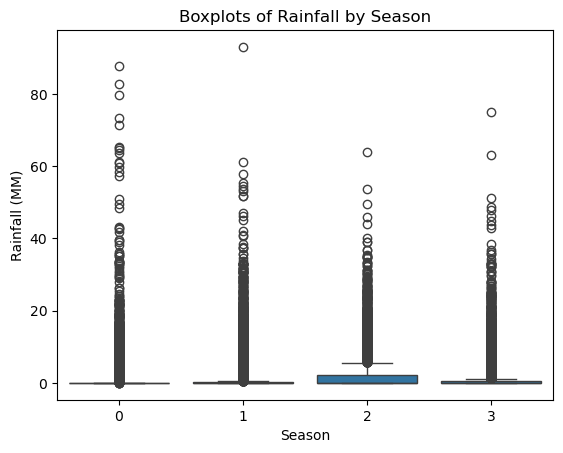

In [46]:
sns.boxplot(data=ad_clean_ses, x='Season', y='Rainfall (MM)')
plt.title('Boxplots of Rainfall by Season');

Observations:

The Graph above shows us that Winter has the lowest amount of rainfall normally, fall and spring have about the same, and summer has the highest amount of rainfall. From the regression line slopes we can see that three out of the four seasons have negative slopes meaning the mean rainfall has gone down. As we expected summer has the biggest negative slope. 

Since the standard error is relatively low compaired to the range of the values (0-93MM rainfall) that means our observed values don't deviate too much from our regression line telling us that the regression line is a fine predictor for our data. 

**Conclusion**

The slope of the regression line is not very drastic but is negative which aligned with our hypothosis. The slope of the regression line is very slight so the change in rainfall is very gradual. We can infer that rainfall over time has become less possibly due to global warming so we reject the null. However, the change is very slight. 

## Prediction

Model Selection. Train-Test-Split, because my data is temporal I can perform a train-test-split but it has to keep its temporality... meaning the split has to be not random. To cut down on the noise of the data I first grouped by year. 

In [47]:
ad_clean = ad_clean.dropna()
ad_clean_yr = ad_clean.groupby('Year').mean().reset_index()
model = LinearRegression()

#training the data
train_size = len(ad_clean_yr) * 0.8
#trained the data on the first 80% and tested on the second 20%
train, test = ad_clean_yr.loc[:train_size], ad_clean_yr.loc[train_size:]
train_x, test_x = train[['Year']], test[['Year']]
train_y, test_y = train[['Rainfall (MM)']], test[['Rainfall (MM)']]

model.fit(train_x, train_y)
pred = model.predict(test_x)
MSE = mean_squared_error(test_y, pred)
MSE

0.09334694164325281

In [48]:
r2 = r2_score(test_y, pred)
r2

-0.12341030509771667

The R^2 score checks the accuracy of the model, because the score is negative that means that the model is not predicting values well at all. 

In [49]:
display(
    np.sqrt(MSE),
    min(ad_clean_yr['Rainfall (MM)']),
    max(ad_clean_yr['Rainfall (MM)'])
)

0.3055273173437243

0.7269662921348314

2.167955801104972

<Axes: xlabel='Year', ylabel='Rainfall (MM)'>

<Axes: xlabel='Year', ylabel='Rainfall (MM)'>

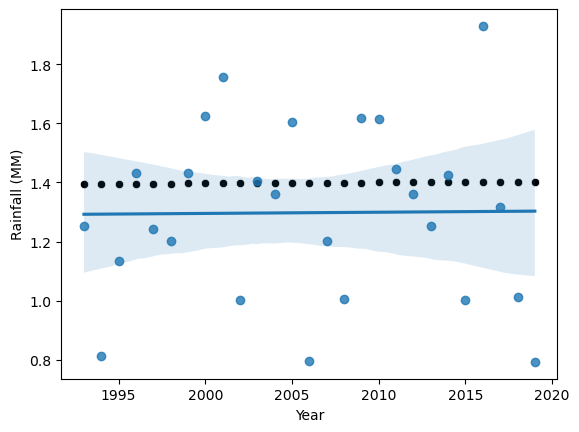

In [50]:
display(
    sns.scatterplot(x= test_x['Year'], y=pred.flatten(), color='black'),
    sns.regplot(x=test_x['Year'], y=test_y['Rainfall (MM)'])
)

Looking at the graph above we can see how the model is constantly over predicting the values, this could be the case because we used the first 80% of data to train the model and if the amount of average rainfall during that time was significantly higher then it would over predict. This could imply that our hypothosis has merit. 

Lets try another model just to be sure. 

In [51]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(train_x, train_y)

pred = model.predict(test_x)

mse = mean_squared_error(test_y, pred)
mse

C:\Users\brook\3\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.21220146501966233

The random forest model did worse at predicting the model. 

In [52]:
r2 = r2_score(test_y, pred)
r2

-1.5537988536462382

<Axes: xlabel='Year', ylabel='Rainfall (MM)'>

<Axes: xlabel='Year', ylabel='Rainfall (MM)'>

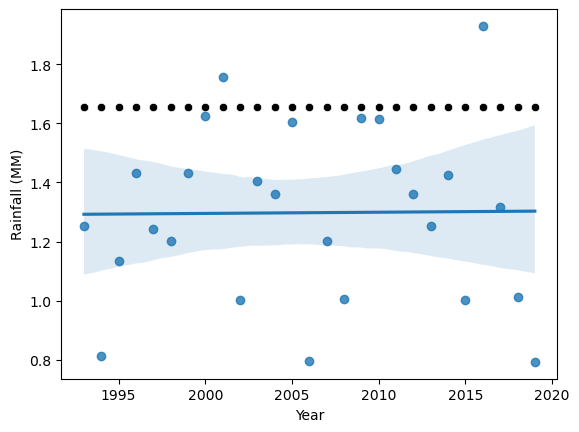

In [53]:
display(
    sns.scatterplot(x= test_x['Year'], y=pred.flatten(), color='black'),
    sns.regplot(x=test_x['Year'], y=test_y['Rainfall (MM)'])
)

Again, the model is not accurately representing the complexity of the data, to account for this lets try to add more features like month and season. 

In [54]:
ad_clean_ses.head()

,Year,Month,Day,Rainfall (MM),Season
2191,1884,1,1,0.0,0
2192,1884,1,2,0.0,0
2193,1884,1,3,0.0,0
2194,1884,1,4,0.0,0
2195,1884,1,5,0.3,0


In [55]:
model = LinearRegression()

#training the data
train_size = len(ad_clean_ses) * 0.8
#trained the data on the first 80% and tested on the second 20%
train, test = ad_clean_ses.loc[:train_size], ad_clean_ses.loc[train_size:]
train_x, test_x = train[['Year', 'Month', 'Season', 'Day']], test[['Year', 'Month', 'Season', 'Day']]
train_y, test_y = train[['Rainfall (MM)']], test[['Rainfall (MM)']]

model.fit(train_x, train_y)
pred = model.predict(test_x)
MSE = mean_squared_error(test_y, pred)
MSE

17.13208811154266

In [56]:
r2 = r2_score(test_y, pred)
r2

0.0044370660454226

Even with adding more predictors our accuracy did not go up by much. The model now is still a poor predictor for our data. 

Let's try once more this time only looking at summer.

In [57]:
summ = ad_clean_ses[ad_clean_ses['Season'] == 2].reset_index()
summ = summ[['Year', 'Month', 'Day', 'Rainfall (MM)']]  #taking out 'Season' and 'index' columns
summ_group = summ.groupby('Year').mean().reset_index()
summ_group.head()

,Year,Month,Day,Rainfall (MM)
0,1884,7.010870,15.836957,1.626087
1,1885,7.010870,15.836957,2.301087
2,1886,7.000000,15.719101,1.513483
3,1887,7.021978,15.802198,2.628571
4,1888,7.010870,15.836957,2.284783


In [58]:
model = LinearRegression()

#trained the data on the first 80% and tested on the second 20%
train, test = summ_group.loc[:108], summ_group.loc[109:]
train_x, test_x = train[['Year', 'Month', 'Day']], test[['Year', 'Month', 'Day']]
train_y, test_y = train[['Rainfall (MM)']], test[['Rainfall (MM)']]

#fitting data
model.fit(train_x, train_y)
pred = model.predict(test_x)
MSE = mean_squared_error(test_y, pred)
MSE

0.5366792556156392

In [59]:
r2 = r2_score(test_y, pred)
r2

-0.30330362242291486

This model did worse again. let's test corrilation again between variables and try cutting out extreme outliers to try and reduce the noise and variance of the data. 

<Axes: >

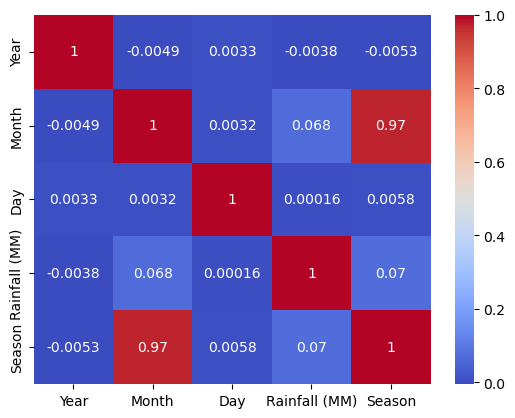

In [60]:
sns.heatmap(ad_clean_ses.corr(), annot=True, cmap="coolwarm")

In [61]:
q1 = ad_clean_ses['Rainfall (MM)'].quantile(0.25)
q3 = ad_clean_ses['Rainfall (MM)'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
ad_clean_out = ad_clean_ses[(ad_clean_ses['Rainfall (MM)'] >= lower_bound) & (ad_clean_ses['Rainfall (MM)'] <= upper_bound)]
ad_clean_out

,Year,Month,Day,Rainfall (MM),Season
2191,1884,1,1,0.0,0
2192,1884,1,2,0.0,0
2193,1884,1,3,0.0,0
2194,1884,1,4,0.0,0
2195,1884,1,5,0.3,0
...,...,...,...,...,...
51859,2019,0,27,0.0,0
51860,2019,0,28,0.0,0
51861,2019,0,29,0.0,0
51862,2019,0,30,0.0,0


In [62]:
model = LinearRegression()

train_size = len(ad_clean_out) * 0.8
#trained the data on the first 80% and tested on the second 20%
train, test = ad_clean_out.loc[:train_size], ad_clean_out.loc[train_size:]
train_x, test_x = train[['Month', 'Season']], test[['Month', 'Season']]   #the top two predictors in the heat map above
train_y, test_y = train[['Rainfall (MM)']], test[['Rainfall (MM)']]

#fitting data
model.fit(train_x, train_y)
pred = model.predict(test_x)
MSE = mean_squared_error(test_y, pred)
MSE

0.04780815642515489

In [63]:
r2 = r2_score(test_y, pred)
r2

0.00873051841135053

## **Conclusion**

The information I have is not enough to create a model that accurately predicts rainfall. Rainfall amounts are effected by more things than just time like location, natural events like hurricanes, temperature, humidity, and wind speed. I don't have any of this data so that could be effecting the models ability to be trained properly. 

Form the regression plots it seems there is a downward trend in rainfall amounts at the station in Australia this data came from but with only the informatin I have I can not confidently reject the null. 